Heart disease predidction using machine learning

1. importing the libraries
   numpy, pandas, matplotlib, seaborn, sklearn
2. loading the dataset
3. EDA(Exploratory Data Analysis)
   shape, info, describe, checking the missing values, distribution of target variable, correlations
4. Splitting the features and target variable
5. Training a model Logistic Reggression, 
6. analysis of the model using confusion matrix, accuracy score
7. Predicting the values using the model

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [6]:
heart_data = pd.read_csv('heart_disease_data.csv')
heart_data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [3]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
heart_data.shape

(303, 14)

In [5]:
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

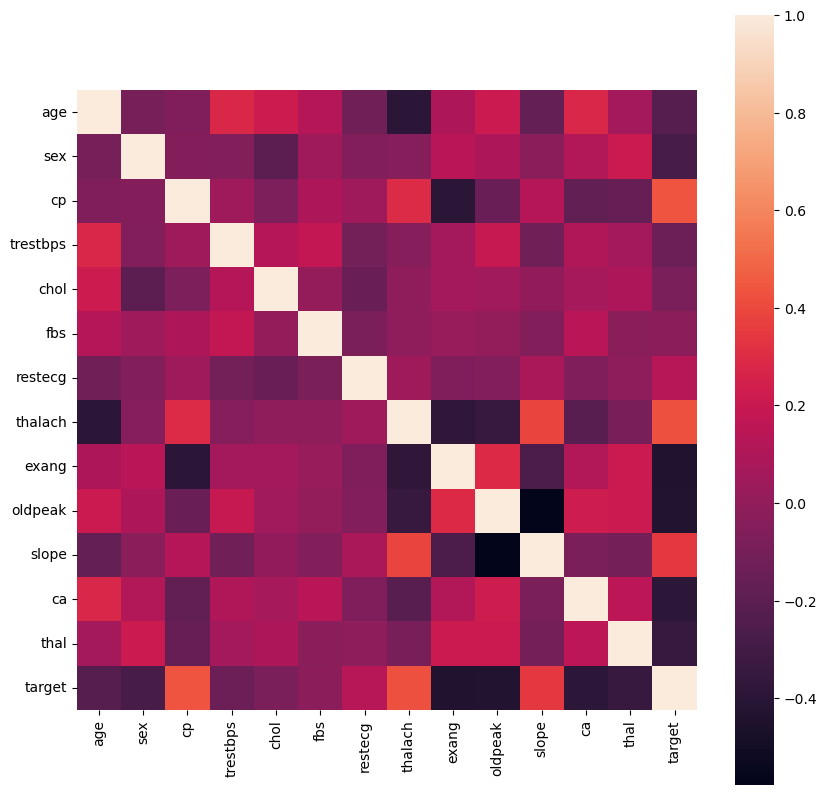

In [8]:
correlation = heart_data.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f')
plt.show()

In [9]:
heart_data['target'].value_counts()



target
1    165
0    138
Name: count, dtype: int64

 prone to heart disease
 1. men vs women
 2. age group

Text(0.5, 1.0, 'Men vs Women')

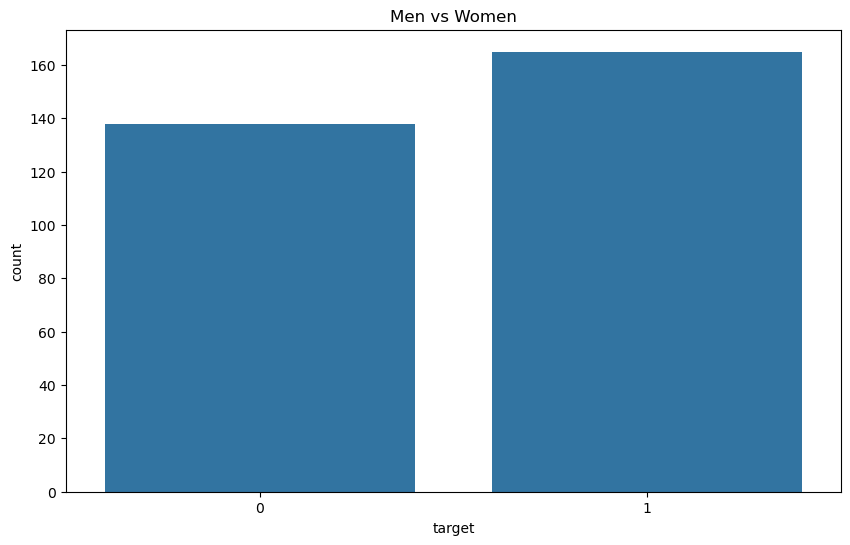

In [53]:
plt.figure(figsize=(10,6))
sns.countplot(x='target', data=heart_data)
plt.title("Men vs Women")

/var/folders/hb/b0ycdv4d5335zq3qm05tnt8w0000gn/T/ipykernel_56437/3021842452.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Ages prone to heart disease')

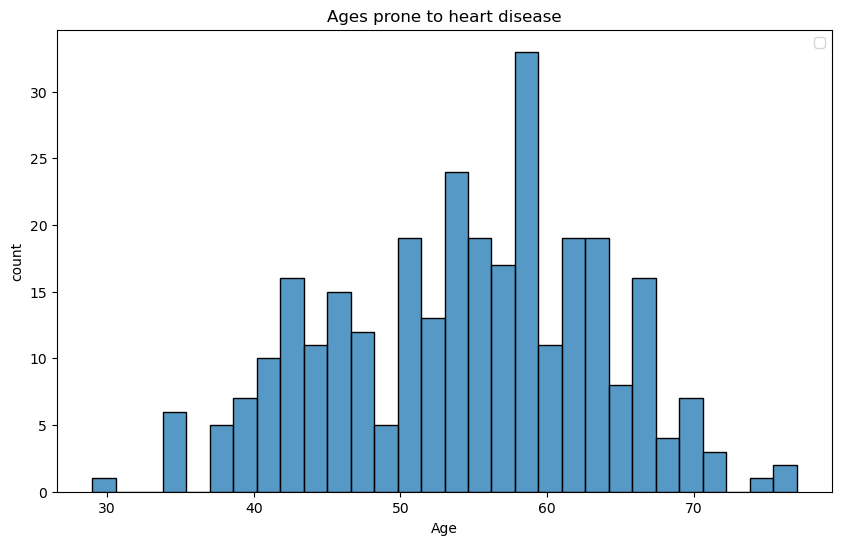

In [56]:
plt.figure(figsize=(10,6))
plt.xlabel('Age')
plt.ylabel('count')
sns.histplot(x='age', data=heart_data, bins=30)
plt.legend()
plt.title("Ages prone to heart disease")

In [ ]:
x = heart_data.drop(columns='target', axis=1)
y = heart_data['target']



In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=200,stratify=y)
model = LogisticRegression()
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
model.fit(x_train, y_train)


LogisticRegression()

In [52]:
x_test_prediction = model.predict(x_test)
x_test_accuracy = accuracy_score(y_test, x_test_prediction)
print('Accuracy of the model is : ', x_test_accuracy)

Accuracy of the model is :  0.8360655737704918


In [51]:
# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 300]
}

grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV accuracy:', grid_search.best_score_)

best_model = grid_search.best_estimator_
best_prediction = best_model.predict(x_test)
best_accuracy = accuracy_score(y_test, best_prediction)
print('Test accuracy with best parameters:', best_accuracy)

Best parameters: {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.830952380952381
Test accuracy with best parameters: 0.8360655737704918
